# Geneformer: checkpoint selection step vs. dataset size

Loads the Geneformer training history that was discovered via
`results/Geneformer/checkpoint-NNNN/trainer_state.json` (same source as
`2026-04-18_09-49_plotting_loss_curves_all_algos.ipynb`) and plots, per
dataset, the optimizer **step at which the best checkpoint was taken**
against the **number of cells** in the training slice. Each (size, quality)
pair contributes one point; color encodes quality.

In [1]:
from pathlib import Path
import json
import re
import pandas as pd

DATA_ROOT = Path('/home/igor/noise_scaling/data')
DATASETS = ['PBMC', 'larry', 'merfish', 'shendure']

_CKPT_RE = re.compile(r'checkpoint-(\d+)$')

In [2]:
# ── Walk the data tree and pull Geneformer best-checkpoint step ────────
# For each (dataset, size, quality) we read the highest-numbered
# checkpoint's trainer_state.json — HF writes a cumulative log_history and
# sets ``best_model_checkpoint`` to the path of the best-so-far checkpoint.
# We pull the step suffix off that path; if it's missing we fall back to
# ``argmin(eval_loss)`` over log_history.

def _is_size_dir(p: Path) -> bool:
    return p.is_dir() and p.name.isdigit()

def _is_quality_dir(p: Path) -> bool:
    if not p.is_dir():
        return False
    try:
        float(p.name); return True
    except ValueError:
        return False

def _latest_trainer_state(gf_root: Path) -> Path | None:
    if not gf_root.is_dir():
        return None
    best, best_step = None, -1
    for p in gf_root.iterdir():
        m = _CKPT_RE.search(p.name)
        if m and p.is_dir():
            step = int(m.group(1))
            ts = p / 'trainer_state.json'
            if ts.exists() and step > best_step:
                best_step, best = step, ts
    return best

def _best_step_from_state(state: dict) -> tuple[int | None, float | None, int, int]:
    """Return (best_step, best_eval_loss, total_steps, max_ckpt_step).
    Prefer the step encoded in ``best_model_checkpoint`` — HuggingFace writes
    that to disk, so it survives relocations of the log."""
    log = state.get('log_history', []) or []
    total_steps = int(state.get('global_step') or 0)
    best_path = state.get('best_model_checkpoint') or ''
    m = _CKPT_RE.search(best_path)
    best_step = int(m.group(1)) if m else None
    # Map step → eval_loss to find the metric, even if best_step came from the path.
    val = {int(e['step']): float(e['eval_loss'])
           for e in log if 'eval_loss' in e and 'step' in e}
    if best_step is None and val:
        best_step = min(val, key=val.get)
    best_val = val.get(best_step) if best_step is not None else None
    max_ckpt_step = max(val) if val else 0
    return best_step, best_val, total_steps, max_ckpt_step

rows = []
for ds in DATASETS:
    ds_dir = DATA_ROOT / ds
    if not ds_dir.is_dir():
        continue
    for size_dir in sorted(filter(_is_size_dir, ds_dir.iterdir()), key=lambda p: int(p.name)):
        size = int(size_dir.name)
        for q_dir in sorted(filter(_is_quality_dir, size_dir.iterdir()), key=lambda p: float(p.name)):
            q = float(q_dir.name)
            ts_path = _latest_trainer_state(q_dir / 'results' / 'Geneformer')
            if ts_path is None:
                continue
            try:
                state = json.loads(ts_path.read_text())
            except Exception:
                continue
            best_step, best_val, total_steps, max_ckpt_step = _best_step_from_state(state)
            if best_step is None:
                continue
            rows.append({
                'dataset': ds, 'size': size, 'quality': q,
                'best_step': best_step, 'best_eval_loss': best_val,
                'total_steps': total_steps,
                'max_ckpt_step': max_ckpt_step,
                'trainer_state': str(ts_path),
            })

df = (pd.DataFrame(rows)
        .sort_values(['dataset', 'size', 'quality'])
        .reset_index(drop=True))
print(f'Loaded {len(df)} Geneformer runs across {df["dataset"].nunique()} datasets')
display(df.head())

Loaded 399 Geneformer runs across 4 datasets


,dataset,size,quality,best_step,best_eval_loss,total_steps,max_ckpt_step,trainer_state
0,PBMC,100,0.001235,1000,7.035635,6000,6000,/home/igor/noise_scaling/data/PBMC/100/0.00123...
1,PBMC,100,0.002598,1000,7.485874,6000,6000,/home/igor/noise_scaling/data/PBMC/100/0.00259...
2,PBMC,100,0.005468,1000,7.400775,6000,6000,/home/igor/noise_scaling/data/PBMC/100/0.00546...
3,PBMC,100,0.011508,1000,7.263443,6000,6000,/home/igor/noise_scaling/data/PBMC/100/0.01150...
4,PBMC,100,0.024220,1000,7.186678,6000,6000,/home/igor/noise_scaling/data/PBMC/100/0.02422...


In [3]:
# Per-(dataset, size) summary: median / min / max best_step across qualities.
import numpy as np

agg = (df.groupby(['dataset', 'size'])['best_step']
         .agg(['median', 'mean', 'min', 'max', 'count'])
         .reset_index())
display(agg)

,dataset,size,median,mean,min,max,count
0,PBMC,100,1000.0,1000.000000,1000,1000,10
1,PBMC,215,2000.0,1600.000000,1000,2000,10
2,PBMC,464,2000.0,2100.000000,1000,3000,10
3,PBMC,1000,4000.0,3500.000000,2000,5000,10
4,PBMC,2154,4500.0,4500.000000,2000,6000,10
5,PBMC,4641,7500.0,7300.000000,3000,12000,10
6,PBMC,10000,12000.0,13200.000000,5000,30000,10
7,PBMC,21544,22500.0,25200.000000,6000,56000,10
8,PBMC,46415,30000.0,40300.000000,22000,87000,10
9,PBMC,100000,33500.0,34500.000000,18000,57000,10


## Best-checkpoint step vs. number of cells — per dataset

Columns = dataset. Inside each subplot, one point per `(size, quality)`
Geneformer run; `x = size (log)`, `y = best_step`, color = quality (log
viridis). A dashed black line traces the median `best_step` per size to
show the trend.

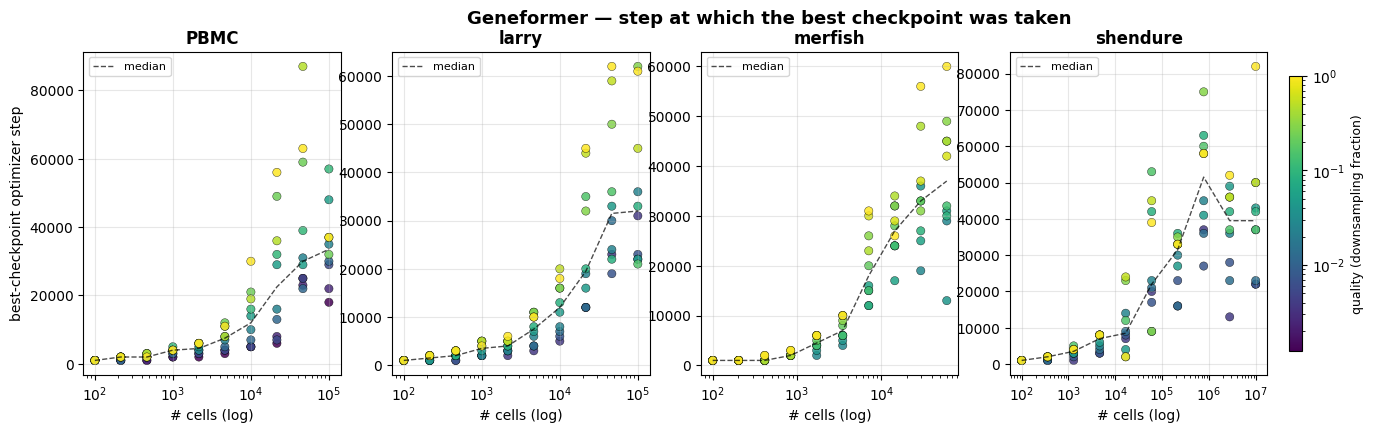

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

ds_list = [ds for ds in DATASETS if ds in df['dataset'].unique()]
if not ds_list:
    print('No Geneformer runs discovered on disk.')
else:
    ncols = len(ds_list)
    fig, axes = plt.subplots(1, ncols, figsize=(4.2 * ncols + 1.5, 4.2),
                             squeeze=False, sharey=False)
    cmap = plt.cm.viridis

    # Shared quality color-norm across all datasets for cross-column comparability.
    all_q = sorted(df['quality'].unique())
    qnorm = mcolors.LogNorm(vmin=min(all_q), vmax=max(all_q))

    for col, ds in enumerate(ds_list):
        ax = axes[0, col]
        sub = df[df['dataset'] == ds]
        colors = cmap(qnorm(sub['quality'].values))
        ax.scatter(sub['size'], sub['best_step'],
                   c=colors, s=36, edgecolor='k', linewidth=0.3, alpha=0.85)

        # Median trend line across qualities.
        trend = (sub.groupby('size')['best_step'].median()
                    .reset_index().sort_values('size'))
        ax.plot(trend['size'], trend['best_step'],
                color='black', linestyle='--', linewidth=1.0, alpha=0.7,
                label='median')

        ax.set_xscale('log')
        ax.set_xlabel('# cells (log)')
        if col == 0:
            ax.set_ylabel('best-checkpoint optimizer step')
        ax.set_title(ds, fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3)
        ax.legend(loc='upper left', fontsize=8, frameon=True)

    # Shared colorbar for quality.
    sm = plt.cm.ScalarMappable(norm=qnorm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.85, pad=0.015)
    cbar.set_label('quality (downsampling fraction)', fontsize=9)

    fig.suptitle('Geneformer — step at which the best checkpoint was taken',
                 fontsize=13, fontweight='bold')
    plt.show()

### All datasets overlaid — median trend per dataset

A single panel showing how the median `best_step` scales with size across
all four datasets. Useful for comparing curve shapes without the quality
scatter.

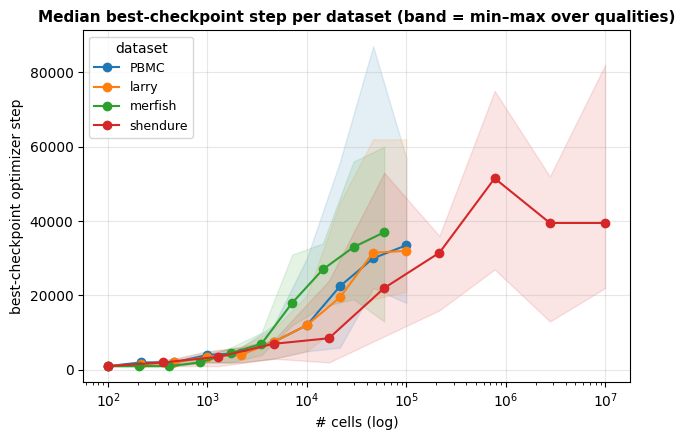

In [5]:
if len(ds_list):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ds_palette = plt.get_cmap('tab10')
    for i, ds in enumerate(ds_list):
        trend = (df[df['dataset'] == ds]
                    .groupby('size')['best_step']
                    .agg(['median', 'min', 'max'])
                    .reset_index()
                    .sort_values('size'))
        color = ds_palette(i)
        ax.plot(trend['size'], trend['median'], marker='o', linewidth=1.5,
                color=color, label=ds)
        ax.fill_between(trend['size'], trend['min'], trend['max'],
                        color=color, alpha=0.12)
    ax.set_xscale('log')
    ax.set_xlabel('# cells (log)')
    ax.set_ylabel('best-checkpoint optimizer step')
    ax.set_title('Median best-checkpoint step per dataset (band = min–max over qualities)',
                 fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(title='dataset', fontsize=9)
    plt.tight_layout()
    plt.show()